In [1]:
# OFDM Performance Analysis - Python Simulation
# Author: Shifa Parveen

In [2]:
# Pipeline: random bits -> QPSK modulation -> IFFT -> Cyclic Prefix ->
# Channel (AWGN or Rayleigh) -> Receiver -> BER vs Eb/N0, plus PAPR analysis.

Setup + Parameters + Bit Generation + QPSK Modulation

In [24]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [25]:
# PARAMETERS
n_bits_total = 256 * 20      # total bits (more data = smoother BER curve)
Nfft = 64                    # number of subcarriers (FFT size)
Ncp = 16                     # cyclic prefix length (25% of Nfft, typical)
EbN0_dB_range = np.arange(0, 21, 2)   # Eb/N0 values to test (dB)
bits_per_symbol = 2          # QPSK
num_trials = 30              # independent trials per Eb/N0 point

rng = np.random.default_rng(seed=42)  # fixed seed = repeatable results; use seed=None for fresh randomness each run

In [26]:
# TRANSMITTER 
bits = rng.integers(0, 2, n_bits_total)

In [27]:
# QPSK mapping (Gray-coded), 2 bits -> 1 symbol
bit_pairs = bits.reshape(-1, 2)
mapping = {
    (0, 0): 1 + 1j,
    (0, 1): -1 + 1j,
    (1, 1): -1 - 1j,
    (1, 0): 1 - 1j,
}
symbols = np.array([mapping[tuple(bp)] for bp in bit_pairs])
symbols = symbols / np.sqrt(2)   # normalize average symbol power to 1

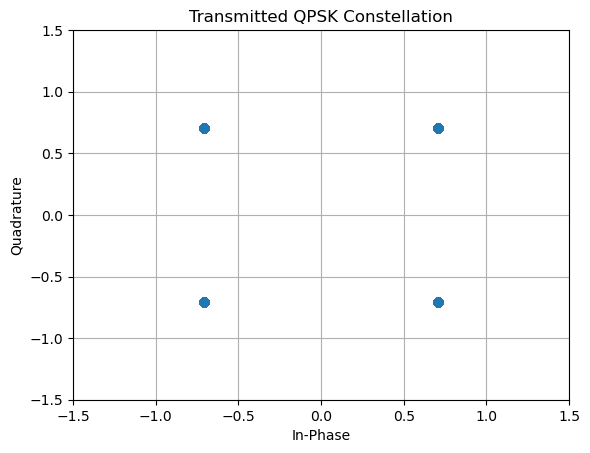

Total symbols: 2560


In [28]:
# Plot constellation
plt.figure()
plt.scatter(symbols.real, symbols.imag)
plt.grid(True)
plt.axis([-1.5, 1.5, -1.5, 1.5])
plt.xlabel('In-Phase')
plt.ylabel('Quadrature')
plt.title('Transmitted QPSK Constellation')
plt.show()

print(f"Total symbols: {len(symbols)}")

OFDM Modulation (IFFT) + Cyclic Prefix

In [29]:
# Split into OFDM blocks
Nsym = Nfft
num_blocks = len(symbols) // Nsym
symbols = symbols[:num_blocks * Nsym]
data_blocks = symbols.reshape(num_blocks, Nsym).T   # Nfft x num_blocks (columns = blocks)

In [30]:
# IFFT: frequency domain -> time domain
ofdm_time = np.fft.ifft(data_blocks, n=Nfft, axis=0)

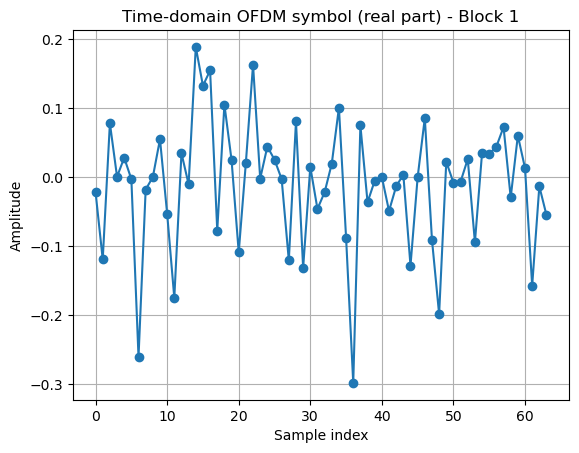

In [31]:
# Plot one time-domain OFDM symbol
plt.figure()
plt.plot(ofdm_time[:, 0].real, 'o-')
plt.grid(True)
plt.xlabel('Sample index')
plt.ylabel('Amplitude')
plt.title('Time-domain OFDM symbol (real part) - Block 1')
plt.show()

In [32]:
# Add cyclic prefix (copy last Ncp samples to the front of each block)
cp_blocks = np.vstack([ofdm_time[-Ncp:, :], ofdm_time])   # (Nfft+Ncp) x num_blocks

In [33]:
# Serialize into one continuous transmitted signal
tx_signal = cp_blocks.flatten(order='F')

In [34]:
print(f"Number of OFDM blocks: {num_blocks}")
print(f"Transmitted signal length: {len(tx_signal)} samples")

Number of OFDM blocks: 40
Transmitted signal length: 3200 samples


PAPR Analysis (channel-independent)

In [35]:
inst_power = np.abs(ofdm_time) ** 2
peak_power = inst_power.max(axis=0)
avg_power = inst_power.mean(axis=0)
papr_per_block_dB = 10 * np.log10(peak_power / avg_power)

In [36]:
# CCDF plot: P(PAPR > x)
sorted_papr = np.sort(papr_per_block_dB)
ccdf = 1.0 - np.arange(1, len(sorted_papr) + 1) / len(sorted_papr)

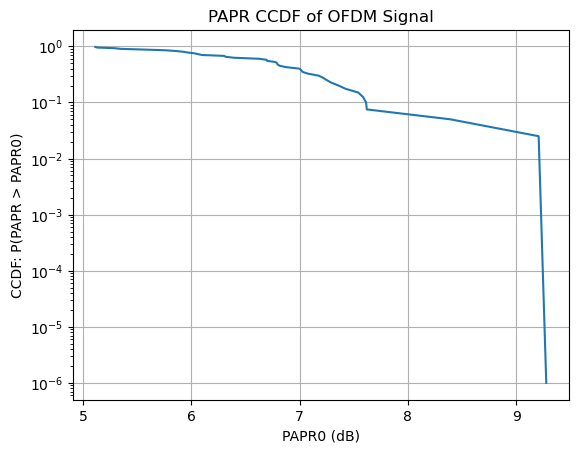

Mean PAPR: 6.76 dB
Max PAPR: 9.28 dB


In [37]:
plt.figure()
plt.semilogy(sorted_papr, np.clip(ccdf, 1e-6, 1))
plt.grid(True)
plt.xlabel('PAPR0 (dB)')
plt.ylabel('CCDF: P(PAPR > PAPR0)')
plt.title('PAPR CCDF of OFDM Signal')
plt.show()

print(f"Mean PAPR: {papr_per_block_dB.mean():.2f} dB")
print(f"Max PAPR: {papr_per_block_dB.max():.2f} dB")

Channel Function + Run BOTH AWGN and Rayleigh Automatically

In [38]:
def awgn_fixed_noise(signal, ref_power, snr_dB, rng):
    """Add white Gaussian noise whose power is set relative to a FIXED reference
    power (the unfaded transmit signal), not the signal actually passed in.
    Essential for Rayleigh: noise power must not silently renormalize to the
    faded signal's power, or fading's effect on SNR disappears."""
    snr_linear = 10 ** (snr_dB / 10)
    noise_power = ref_power / snr_linear
    noise = np.sqrt(noise_power / 2) * (rng.standard_normal(signal.shape) + 1j * rng.standard_normal(signal.shape))
    return signal + noise

In [39]:
ref_signal_power = np.mean(np.abs(tx_signal) ** 2)   # fixed reference, computed once

In [40]:
def run_ber_sweep(channel_type):
    """Runs the full receiver pipeline across all Eb/N0 points for the given
    channel_type ('AWGN' or 'Rayleigh') and returns the BER array."""
    ber_results = np.zeros(len(EbN0_dB_range))

    for idx, ebn0_db in enumerate(EbN0_dB_range):
        snr_dB = ebn0_db + 10 * np.log10(bits_per_symbol) + 10 * np.log10(Nfft / (Nfft + Ncp))

        total_errors = 0
        total_bits = 0

        for trial in range(num_trials):
            if channel_type == 'AWGN':
                rx_signal = awgn_fixed_noise(tx_signal, ref_signal_power, snr_dB, rng)
                h = 1.0
            elif channel_type == 'Rayleigh':
                h = (rng.standard_normal() + 1j * rng.standard_normal()) / np.sqrt(2)
                rx_signal = awgn_fixed_noise(h * tx_signal, ref_signal_power, snr_dB, rng)
            else:
                raise ValueError("channel_type must be 'AWGN' or 'Rayleigh'")

            rx_blocks = rx_signal.reshape(num_blocks, Nfft + Ncp).T
            rx_no_cp = rx_blocks[Ncp:, :]
            rx_freq = np.fft.fft(rx_no_cp, n=Nfft, axis=0)

            if channel_type == 'Rayleigh':
                rx_freq = rx_freq / h

            rx_symbols = rx_freq.flatten(order='F')

            rx_bits = np.zeros(2 * len(rx_symbols), dtype=int)
            re, im = rx_symbols.real, rx_symbols.imag
            for k in range(len(rx_symbols)):
                if re[k] >= 0 and im[k] >= 0:
                    b = (0, 0)
                elif re[k] < 0 and im[k] >= 0:
                    b = (0, 1)
                elif re[k] < 0 and im[k] < 0:
                    b = (1, 1)
                else:
                    b = (1, 0)
                rx_bits[2 * k] = b[0]
                rx_bits[2 * k + 1] = b[1]

            tx_bits_trimmed = bits[:len(rx_bits)]
            total_errors += np.sum(rx_bits != tx_bits_trimmed)
            total_bits += len(rx_bits)

        ber_results[idx] = total_errors / total_bits

    return ber_results

In [41]:
print("Running AWGN sweep...")
ber_awgn = run_ber_sweep('AWGN')

print("Running Rayleigh sweep...")
ber_rayleigh = run_ber_sweep('Rayleigh')

print("Done.")

Running AWGN sweep...
Running Rayleigh sweep...
Done.


Plot Both BER Curves + Summary

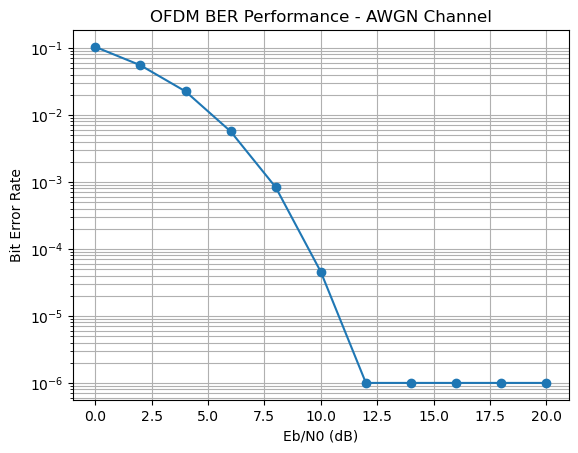

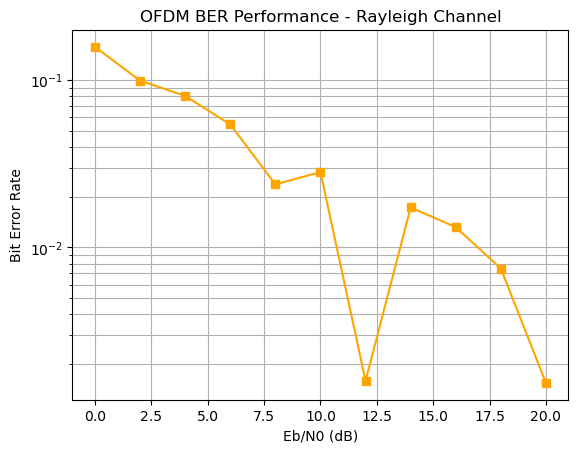

In [42]:
# Individual plots
plt.figure()
plt.semilogy(EbN0_dB_range, np.clip(ber_awgn, 1e-6, 1), 'o-')
plt.grid(True, which='both')
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('Bit Error Rate')
plt.title('OFDM BER Performance - AWGN Channel')
plt.show()

plt.figure()
plt.semilogy(EbN0_dB_range, np.clip(ber_rayleigh, 1e-6, 1), 's-', color='orange')
plt.grid(True, which='both')
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('Bit Error Rate')
plt.title('OFDM BER Performance - Rayleigh Channel')
plt.show()

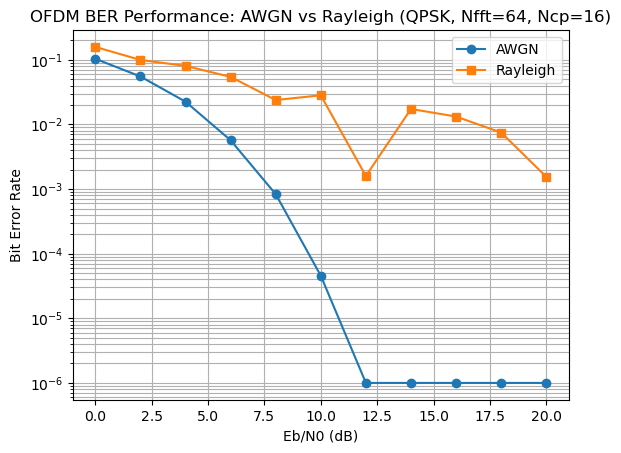

In [43]:
# Combined comparison plot (the key result figure)
plt.figure()
plt.semilogy(EbN0_dB_range, np.clip(ber_awgn, 1e-6, 1), 'o-', label='AWGN')
plt.semilogy(EbN0_dB_range, np.clip(ber_rayleigh, 1e-6, 1), 's-', label='Rayleigh')
plt.grid(True, which='both')
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('Bit Error Rate')
plt.title(f'OFDM BER Performance: AWGN vs Rayleigh (QPSK, Nfft={Nfft}, Ncp={Ncp})')
plt.legend()
plt.show()

In [44]:
# SUMMARY
print(f"\n--- Simulation Summary ---")
print(f"Nfft = {Nfft}, Ncp = {Ncp}, Total bits = {n_bits_total}, Blocks = {num_blocks}")
print(f"Mean PAPR = {papr_per_block_dB.mean():.2f} dB")
print("\nBER at each Eb/N0 (dB):")
print(f"{'Eb/N0 (dB)':>12} | {'AWGN BER':>12} | {'Rayleigh BER':>14}")
for ebn0, ber_a, ber_r in zip(EbN0_dB_range, ber_awgn, ber_rayleigh):
    print(f"{ebn0:>12} | {ber_a:>12.6f} | {ber_r:>14.6f}")


--- Simulation Summary ---
Nfft = 64, Ncp = 16, Total bits = 5120, Blocks = 40
Mean PAPR = 6.76 dB

BER at each Eb/N0 (dB):
  Eb/N0 (dB) |     AWGN BER |   Rayleigh BER
           0 |     0.103730 |       0.158275
           2 |     0.055182 |       0.099505
           4 |     0.022493 |       0.080560
           6 |     0.005684 |       0.054427
           8 |     0.000833 |       0.023854
          10 |     0.000046 |       0.028229
          12 |     0.000000 |       0.001595
          14 |     0.000000 |       0.017350
          16 |     0.000000 |       0.013236
          18 |     0.000000 |       0.007487
          20 |     0.000000 |       0.001549
